In [1]:
import numpy as np
from scipy.spatial.transform import Rotation


In [2]:
def generate_so3_random_rotations(N, prior_cfg=None):
    """
    Build an SO(3) node set by random sampling.
    
    Parameters
    ----------
    N : int
        Number of rotations to sample
    prior_cfg : dict, optional
        Configuration with keys (applies to *weights*, not sampling):
        - 'mode': 'uniform' or 'iso-gaussian'
        - 'sigma': std (radians) for geodesic Gaussian (if 'iso-gaussian')
        - 'center': dict describing mean rotation R0:
                    - 'type': 'identity' | 'axis-angle' | 'matrix'
                    - if 'axis-angle': 'axis' (1x3), 'angle' (rad)
                    - if 'matrix': 'R0' (3x3 rotation)
    
    Returns
    -------
    rotation_axis : ndarray, shape (N, 3)
        Unit vectors
    rotation_angle : ndarray, shape (N,)
        Angles in [0, pi]
    grid_R : ndarray, shape (N, 3, 3)
        Rotation matrices
    w : ndarray, shape (N,)
        Nonnegative weights summing to 1
    
    Notes
    -----
    - The prior_cfg controls *weights* (importance reweighting for MMSE).
    - If both sampling and prior are non-uniform, you intentionally bias twice.
    """
    
    if prior_cfg is None:
        prior_cfg = {'mode': 'uniform'}
    
    rotation_axis = np.zeros((N, 3))
    rotation_angle = np.zeros(N)
    grid_R = np.zeros((N, 3, 3))
    
    mode = prior_cfg.get('mode', 'uniform').lower()
    
    if mode == "uniform":
        # Haar measure via random normalized quaternion
        for i in range(N):
            q = np.random.randn(4)
            q = q / max(np.linalg.norm(q), np.finfo(float).eps)
            
            # Convert quaternion to axis-angle using scipy
            # scipy uses [x, y, z, w] format, we have [w, x, y, z] from MATLAB
            # Actually, randn generates [q0, q1, q2, q3], we normalize and convert
            rot = Rotation.from_quat(np.roll(q, -1))  # Convert to scipy format [x,y,z,w]
            rotvec = rot.as_rotvec()  # rotation vector = axis * angle
            
            angle = np.linalg.norm(rotvec)
            if angle > np.finfo(float).eps:
                axis = rotvec / angle
            else:
                axis = np.array([1.0, 0.0, 0.0])
                angle = 0.0
            
            rotation_axis[i, :] = axis
            rotation_angle[i] = angle
            grid_R[i, :, :] = rot.as_matrix()
    
    elif mode == "iso-gaussian":
        # Axis ~ uniform on S^2; angle ~ wrapped Gaussian over [0, pi]
        eps_c = max(prior_cfg.get('sigma', 1.0), 1e-12)
        omega = np.linspace(0, np.pi, 2000)
        
        # Wrapped Gaussian-like density on SO(3) by geodesic radius
        sin_half = np.sin(omega / 2)
        sin_half = np.where(np.abs(sin_half) < np.finfo(float).eps, 
                           np.finfo(float).eps, sin_half)
        
        f = (1 - np.cos(omega)) * np.pi * eps_c**(-3/2) * np.exp(eps_c/4 - (omega/2)**2/eps_c) * \
            (omega - np.exp(-np.pi**2/eps_c) * 
             ((omega - 2*np.pi) * np.exp(np.pi*omega/eps_c) + 
              (omega + 2*np.pi) * np.exp(-np.pi*omega/eps_c)) / (2*sin_half))
        
        f = np.maximum(f, 0)
        F = np.concatenate([[0], np.cumsum(f[1:])])  # CDF
        F = F / max(F[-1], np.finfo(float).eps)
        
        for i in range(N):
            # Random axis on unit sphere
            v = np.random.randn(3)
            v = v / max(np.linalg.norm(v), np.finfo(float).eps)
            rotation_axis[i, :] = v
            
            # Sample angle from inverse CDF
            u = np.random.rand()
            k = np.argmin(np.abs(F - u))
            theta = omega[k]
            rotation_angle[i] = theta
            
            # Create rotation from axis-angle
            rot = Rotation.from_rotvec(v * theta)
            grid_R[i, :, :] = rot.as_matrix()
    
    else:
        raise ValueError(f'generate_so3_random_rotations: unknown mode = {mode}')
    
    # Base weights: uniform over sampled nodes
    w = np.ones(N) / max(N, 1)
    
    return rotation_axis, rotation_angle, grid_R, w

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
N = 100
prior_cfg = {
    'mode': 'iso-gaussian',
    'sigma': 0.3  # Standard deviation in radians
}

rotation_axis_g, rotation_angle_g, grid_R_g, w_g = generate_so3_random_rotations(N, prior_cfg)


Visualizing rotation 0:
Axis: [0.61205741 0.79057812 0.01928664]
Angle: 1.72 rad (98.3°)


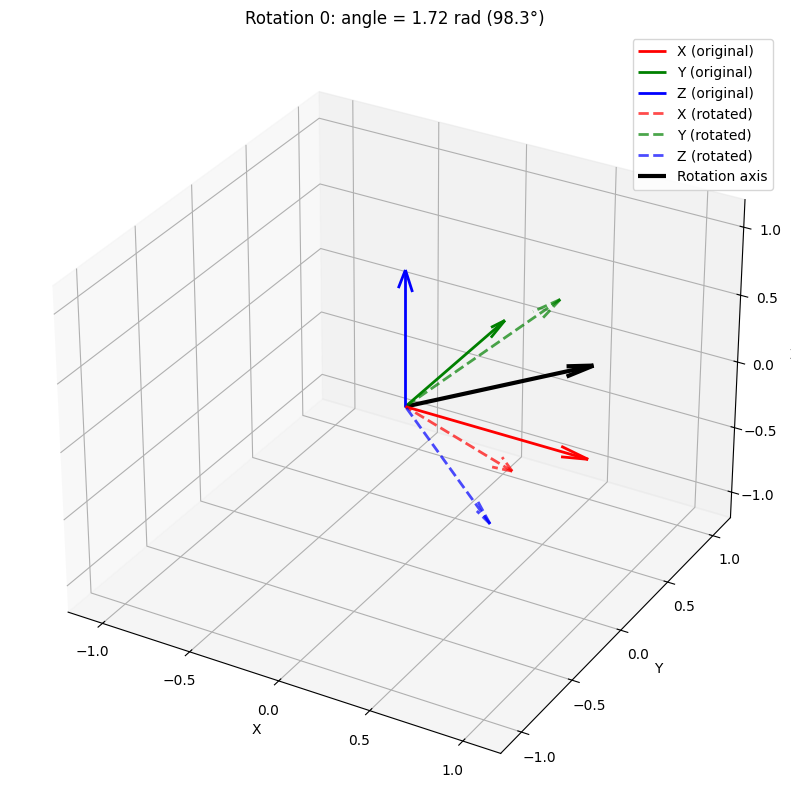

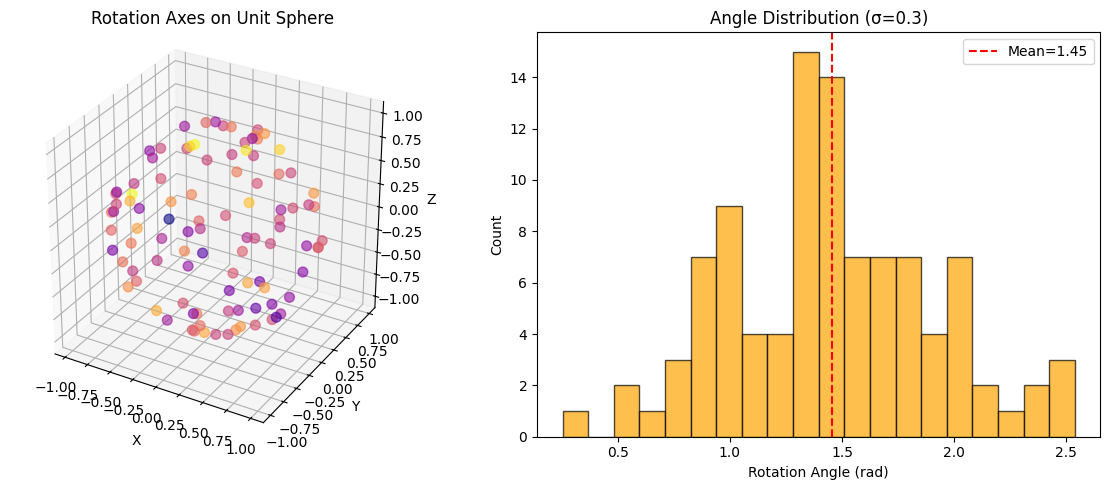

In [8]:
# Visualize a single rotation
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Original coordinate frame
origin = np.array([0, 0, 0])
axes_original = np.eye(3)
colors = ['r', 'g', 'b']
labels = ['X', 'Y', 'Z']

# Plot original axes
for i in range(3):
    ax.quiver(*origin, *axes_original[i], color=colors[i], 
              arrow_length_ratio=0.15, linewidth=2, label=f'{labels[i]} (original)')
idx = 0
# Apply rotation and plot transformed axes
R = grid_R_g[idx]
for i in range(3):
    rotated = R @ axes_original[i]
    ax.quiver(*origin, *rotated, color=colors[i], 
              arrow_length_ratio=0.15, linewidth=2, linestyle='--', 
              alpha=0.7, label=f'{labels[i]} (rotated)')

# Plot rotation axis
axis = rotation_axis_g[idx]
angle = rotation_angle_g[idx]
ax.quiver(*origin, *axis, color='k', arrow_length_ratio=0.15, 
          linewidth=3, label=f'Rotation axis')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])
ax.legend()
ax.set_title(f'Rotation {idx}: angle = {angle:.2f} rad ({np.degrees(angle):.1f}°)')
plt.show()

# Visualize rotation axes on sphere
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(rotation_axis_g[:, 0], rotation_axis_g[:, 1], rotation_axis_g[:, 2],
           c=rotation_angle_g, cmap='plasma', s=50, alpha=0.6)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('Rotation Axes on Unit Sphere')
ax1.set_box_aspect([1, 1, 1])

# Angle histogram
ax2 = fig.add_subplot(122)
ax2.hist(rotation_angle_g, bins=20, alpha=0.7, edgecolor='black', color='orange')
ax2.set_xlabel('Rotation Angle (rad)')
ax2.set_ylabel('Count')
ax2.set_title(f'Angle Distribution (σ={prior_cfg["sigma"]})')
ax2.axvline(np.mean(rotation_angle_g), color='r', linestyle='--', 
           label=f'Mean={np.mean(rotation_angle_g):.2f}')
ax2.legend()

plt.tight_layout()
plt.show()


Example 1: Uniform sampling
Number of samples: 100
Rotation axes shape: (100, 3)
Rotation angles shape: (100,)
Rotation matrices shape: (100, 3, 3)
Weights shape: (100,)
Weights sum: 1.000000
First rotation axis: [ 0.62996077 -0.30419119 -0.71457481]
First rotation angle: 2.9039 rad (166.38 deg)
First rotation matrix:
[[-0.18933983 -0.20961068 -0.95927775]
 [-0.54612716 -0.78941975  0.2802884 ]
 [-0.81602424  0.57695738  0.03499452]]

Example 2: Iso-Gaussian sampling
Sigma: 0.3 rad (17.19 deg)
Mean angle: 1.4640 rad (83.88 deg)
Std angle: 0.5373 rad (30.79 deg)

Example 3: Verify rotation matrix properties
Det(R) = 1.000000 (should be 1)
R^T @ R =
[[ 1.00000000e+00  5.90124614e-17 -5.27694429e-17]
 [ 5.90124614e-17  1.00000000e+00 -1.73526680e-17]
 [-5.27694429e-17 -1.73526680e-17  1.00000000e+00]]
Is orthogonal? True

Example 4: Apply rotation to vector
Original vector: [1. 0. 0.]
Rotated vector: [-0.18933983 -0.54612716 -0.81602424]
Rotation preserves length? True

Visualization save

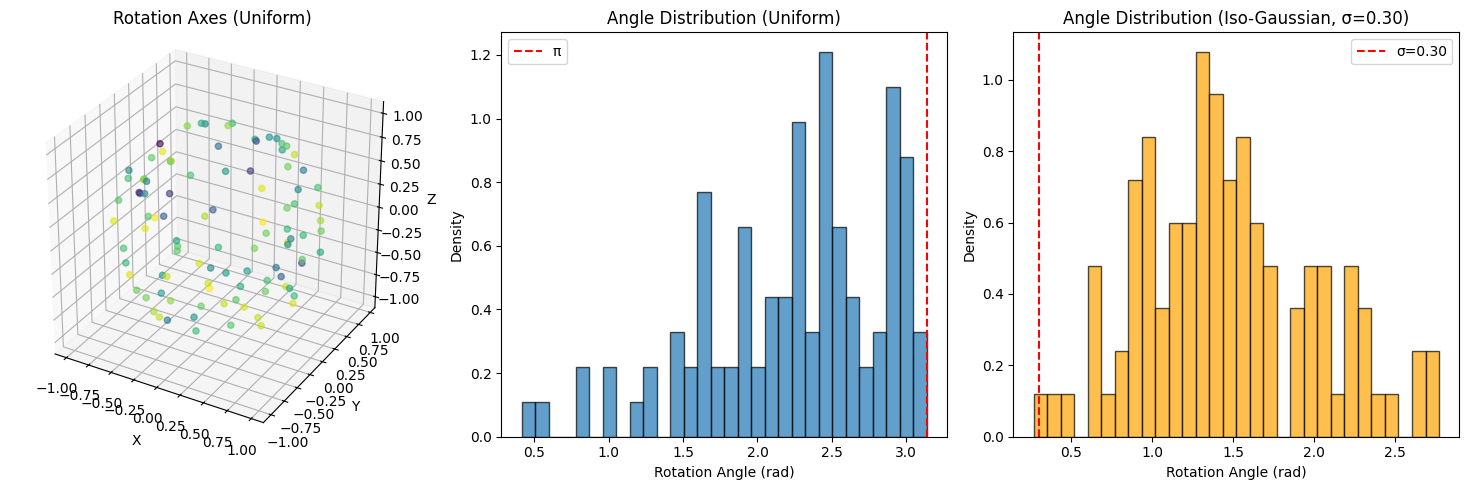


Example 5: Compare different sigma values
Sigma comparison saved as 'so3_sigma_comparison.png'


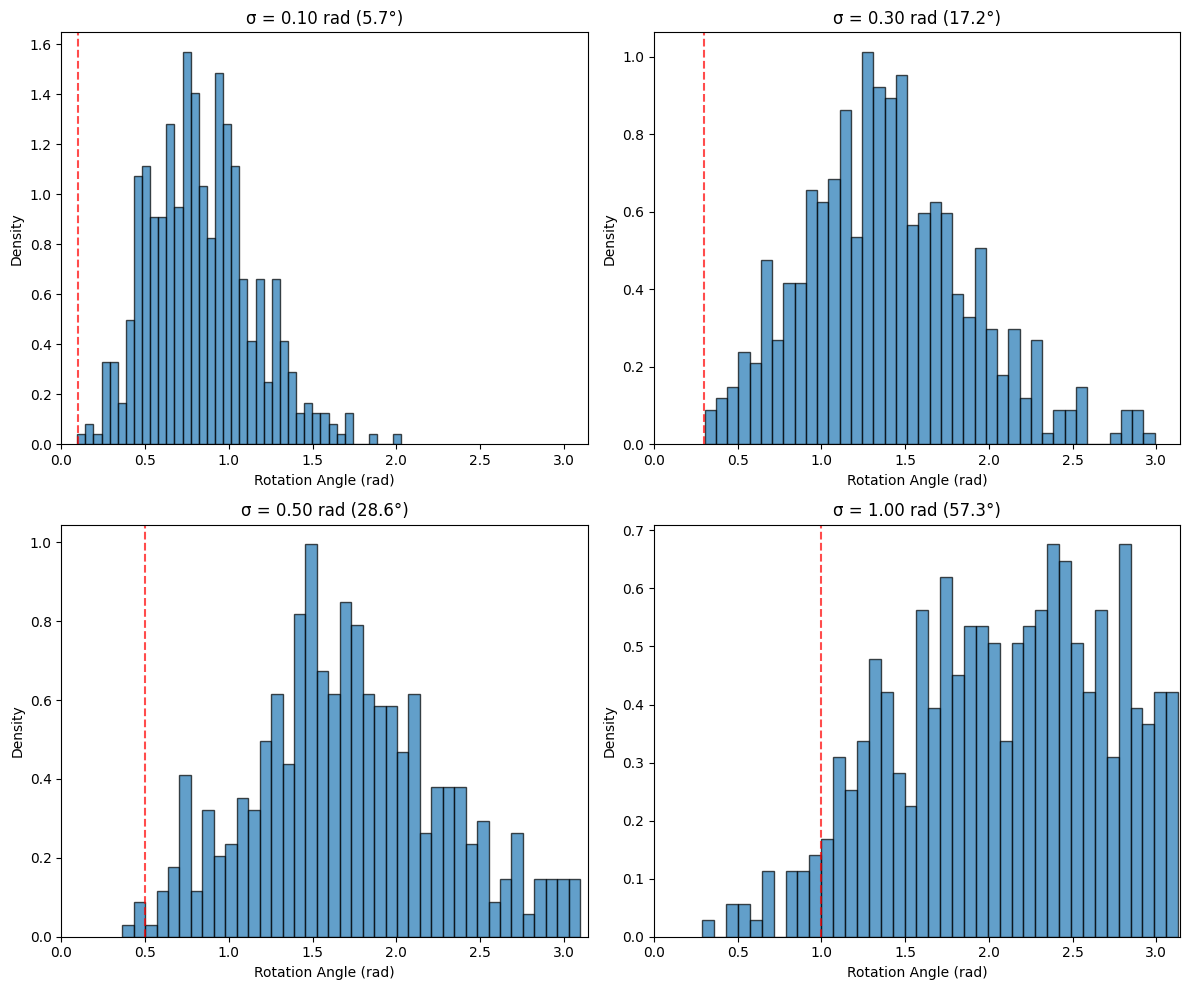

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Example 1: Uniform sampling (Haar measure)
print("Example 1: Uniform sampling")
N = 100
rotation_axis, rotation_angle, grid_R, w = generate_so3_random_rotations(N)

print(f"Number of samples: {N}")
print(f"Rotation axes shape: {rotation_axis.shape}")
print(f"Rotation angles shape: {rotation_angle.shape}")
print(f"Rotation matrices shape: {grid_R.shape}")
print(f"Weights shape: {w.shape}")
print(f"Weights sum: {np.sum(w):.6f}")
print(f"First rotation axis: {rotation_axis[0]}")
print(f"First rotation angle: {rotation_angle[0]:.4f} rad ({np.degrees(rotation_angle[0]):.2f} deg)")
print(f"First rotation matrix:\n{grid_R[0]}\n")

# Example 2: Iso-Gaussian sampling
print("Example 2: Iso-Gaussian sampling")
prior_cfg = {
    'mode': 'iso-gaussian',
    'sigma': 0.3  # Standard deviation in radians
}
rotation_axis_g, rotation_angle_g, grid_R_g, w_g = generate_so3_random_rotations(N, prior_cfg)

print(f"Sigma: {prior_cfg['sigma']} rad ({np.degrees(prior_cfg['sigma']):.2f} deg)")
print(f"Mean angle: {np.mean(rotation_angle_g):.4f} rad ({np.degrees(np.mean(rotation_angle_g)):.2f} deg)")
print(f"Std angle: {np.std(rotation_angle_g):.4f} rad ({np.degrees(np.std(rotation_angle_g)):.2f} deg)\n")

# Example 3: Verify rotation properties
print("Example 3: Verify rotation matrix properties")
R = grid_R[0]
print(f"Det(R) = {np.linalg.det(R):.6f} (should be 1)")
print(f"R^T @ R =\n{R.T @ R}")
print(f"Is orthogonal? {np.allclose(R.T @ R, np.eye(3))}\n")

# Example 4: Apply rotation to a vector
print("Example 4: Apply rotation to vector")
v = np.array([1.0, 0.0, 0.0])
v_rotated = grid_R[0] @ v
print(f"Original vector: {v}")
print(f"Rotated vector: {v_rotated}")
print(f"Rotation preserves length? {np.allclose(np.linalg.norm(v), np.linalg.norm(v_rotated))}\n")

# Visualization
fig = plt.figure(figsize=(15, 5))

# Plot 1: Rotation axes on unit sphere (uniform)
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(rotation_axis[:, 0], rotation_axis[:, 1], rotation_axis[:, 2], 
            c=rotation_angle, cmap='viridis', s=20, alpha=0.6)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('Rotation Axes (Uniform)')
ax1.set_box_aspect([1,1,1])

# Plot 2: Rotation angle histogram (uniform)
ax2 = fig.add_subplot(132)
ax2.hist(rotation_angle, bins=30, alpha=0.7, edgecolor='black', density=True)
ax2.set_xlabel('Rotation Angle (rad)')
ax2.set_ylabel('Density')
ax2.set_title('Angle Distribution (Uniform)')
ax2.axvline(np.pi, color='r', linestyle='--', label='π')
ax2.legend()

# Plot 3: Rotation angle histogram (iso-Gaussian)
ax3 = fig.add_subplot(133)
ax3.hist(rotation_angle_g, bins=30, alpha=0.7, edgecolor='black', density=True, color='orange')
ax3.set_xlabel('Rotation Angle (rad)')
ax3.set_ylabel('Density')
ax3.set_title(f'Angle Distribution (Iso-Gaussian, σ={prior_cfg["sigma"]:.2f})')
ax3.axvline(prior_cfg['sigma'], color='r', linestyle='--', label=f'σ={prior_cfg["sigma"]:.2f}')
ax3.legend()

plt.tight_layout()
plt.savefig('so3_rotations.png', dpi=150, bbox_inches='tight')
print("Visualization saved as 'so3_rotations.png'")
plt.show()

# Example 5: Compare multiple sigma values
print("\nExample 5: Compare different sigma values")
sigmas = [0.1, 0.3, 0.5, 1.0]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, sigma in enumerate(sigmas):
    cfg = {'mode': 'iso-gaussian', 'sigma': sigma}
    _, angles, _, _ = generate_so3_random_rotations(500, cfg)
    
    axes[idx].hist(angles, bins=40, alpha=0.7, edgecolor='black', density=True)
    axes[idx].set_xlabel('Rotation Angle (rad)')
    axes[idx].set_ylabel('Density')
    axes[idx].set_title(f'σ = {sigma:.2f} rad ({np.degrees(sigma):.1f}°)')
    axes[idx].axvline(sigma, color='r', linestyle='--', alpha=0.7)
    axes[idx].set_xlim([0, np.pi])

plt.tight_layout()
plt.savefig('so3_sigma_comparison.png', dpi=150, bbox_inches='tight')
print("Sigma comparison saved as 'so3_sigma_comparison.png'")
plt.show()